In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Compulsory Assignment 2: Convolutional neural networks

# Assignment Submission
To complete this assignment answer the relevant questions in this notebook and write the code required to implement the relevant models. The assignment is submitted by handing in this notebook as an .ipynb file and as a .pdf file.

# Introduction
In this assignment, you will build a Convolutional Neural Network (CNN) to classify images of natural scenes from around the world.
Dataset: Intel-image-classification
https://www.kaggle.com/datasets/puneet6060/intel-image-classification

This Data contains around 25k images of size 150x150 distributed under 6 categories.
{'buildings' -> 0,
'forest' -> 1,
'glacier' -> 2,
'mountain' -> 3,
'sea' -> 4,
'street' -> 5 }

#### In CA2, we use only 3 classes "buildings", "forest", "sea".

This data was initially published on https://datahack.analyticsvidhya.com by Intel to host a Image classification Challenge.
## Landscape Pictures

Example image:


<center><img src="20497.jpg" width="500" height="400"></center>


## Assignment structure

1. Part 0: Setup & Data
2. Part 1: Baseline CNN (Clean Data)
3. Part 2: Choose Your Robustness Challenges
4. Part 3: Results & Comparison

```

## Library imports

In [ ]:
# Feel free to add or remove libraries as you want
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow.keras as ks


# Part 0: Setup & Data, CNN for Landscape Picture dataset
### NOTE FOR STUDENTS:

Do not forget to change the path of root_dir below so it points to the Intel folder which contains the dataset inside your CA2 directory.
### Example:

Windows: r"C:\Users\yourname\...\CA2\Intel"

Mac/Linux: "/home/yourname/CA2/Intel"

## Loading DATASET

In [ ]:
#får feilmelding når man skal importere utilities så måtte endre litt på koden slik at den skulle kjøre
import sys, os, importlib

UTILS_DIR = "/content/drive/MyDrive/CA2/CA2"
if UTILS_DIR not in sys.path:
    sys.path.append(UTILS_DIR)

import utilities
importlib.reload(utilities)
from utilities import load_intel_dataset

ROOT_DIR = "/content/drive/MyDrive/CA2/CA2/Intel"
assert os.path.isdir(ROOT_DIR), f"Folder not found: {ROOT_DIR}"

#setter til 96x96 for å spare RAM, sliter med dette
# Load dataset
data = load_intel_dataset(
    root_dir=ROOT_DIR,
    img_size=(96, 96),
    selected_classes=["buildings", "forest", "sea"],
    verbose=1
)

X_train, y_train = data["X_train"], data["y_train"]
X_val,   y_val   = data["X_val"],   data["y_val"]
X_test,  y_test  = data["X_test"],  data["y_test"]
class_names      = data["class_names"]

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape,   y_val.shape)
print("Test: ", X_test.shape,  y_test.shape)

# Show number of images per class
import numpy as np
def count_per_class(y, split_name):
    u, c = np.unique(y, return_counts=True)
    print(f"\n{split_name} set class distribution:")
    for cls, cnt in zip(u, c):
        print(f"  {class_names[int(cls)]}: {int(cnt)}")

count_per_class(y_train, "Train")
count_per_class(y_val,   "Val")
count_per_class(y_test,  "Test")




[train] Loaded 500/6736 images
[train] Loaded 1000/6736 images
[train] Loaded 1500/6736 images
[train] Loaded 2000/6736 images
[train] Loaded 2500/6736 images
[train] Loaded 3000/6736 images
[train] Loaded 3500/6736 images
[train] Loaded 4000/6736 images
[train] Loaded 4500/6736 images
[train] Loaded 5000/6736 images
[train] Loaded 5500/6736 images
[train] Loaded 6000/6736 images
[train] Loaded 6500/6736 images
[train] Loaded 6736/6736 images
[test] Loaded 500/1421 images
[test] Loaded 1000/1421 images
[test] Loaded 1421/1421 images
Final shapes → Train: (6062, 96, 96, 3), Val: (674, 96, 96, 3), Test: (1421, 96, 96, 3)
Classes: ['buildings', 'forest', 'sea']
Train: (6062, 96, 96, 3) (6062,)
Val:   (674, 96, 96, 3) (674,)
Test:  (1421, 96, 96, 3) (1421,)

Train set class distribution:
  buildings: 1972
  forest: 2044
  sea: 2046

Val set class distribution:
  buildings: 219
  forest: 227
  sea: 228

Test set class distribution:
  buildings: 437
  forest: 474
  sea: 510


## Preprocessing


In [ ]:

# Normalizing input between [0,1]
X_train = X_train.astype("float32") / 255.0 if X_train.size else X_train
X_val   = X_val.astype("float32")   / 255.0 if X_val.size else X_val
X_test  = X_test.astype("float32")  / 255.0 if X_test.size else X_test

# Converting targets from numbers to categorical format
if y_train is not None and y_train.size:
    num_classes = len(np.unique(y_train))
    y_train = ks.utils.to_categorical(y_train, num_classes)

if y_val is not None and y_val.size:
    y_val = ks.utils.to_categorical(y_val, num_classes)

if y_test is not None and y_test.size:
    y_test = ks.utils.to_categorical(y_test, num_classes)

print("X_train shape:", X_train.shape)
print("X_val shape:",   X_val.shape)
print("X_test shape:",  X_test.shape)



X_train shape: (6062, 96, 96, 3)
X_val shape: (674, 96, 96, 3)
X_test shape: (1421, 96, 96, 3)


## Part 1: Build a CNN network with the LeNet5 architecture

##### Implement LeNet5 architecture for Landscape Pictures (RGB):

--------------------------
The LeNet architecture takes a 32×32×C image as input, where C is the number of color channels. You may use resize_dataset() and f1_score() from utilities.py¶

Input & resizing: Resize all images to 32×32 and use C = 3 channels (RGB).
If you choose a different input size, update the intermediate shapes accordingly, but keep the LeNet-5 pattern (Conv → Pool → Conv → Pool → FC → FC → FC).

**Layer 1 - Convolution (5x5):** The output shape should be 28x28x6. **Activation:** ReLU.

**MaxPooling:** The output shape should be 14x14x6.

**Layer 2 - Convolution (5x5):** The output shape should be 10x10x16. **Activation:** ReLU.

**MaxPooling:** The output shape should be 5x5x16.

**Flatten:** Flatten the output shape of the final pooling layer such that it's 1D instead of 3D.  You may need to use tf.reshape.

**Layer 3 - Fully Connected:** This should have 120 outputs. **Activation:** ReLU.

**Layer 4 - Fully Connected:** This should have 84 outputs. **Activation:** ReLU.

**Layer 5 - Fully Connected (output):** **`num_classes`**. **Activation:** softmax

--------------------------


##### Compile the network with the
* `tf.keras.losses.CategoricalCrossentropy` loss function
* the `adam` optimizer
* with the `accuracy` metric and (your own implementation of the) F1-score metric.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

#resizer bildene til 32x32
def resize_to_32(x):
    x_tf = tf.convert_to_tensor(x, dtype=tf.float16)
    x_res = tf.image.resize(x_tf, (32, 32), method="bilinear")
    return x_res.numpy()

X_train_32 = resize_to_32(X_train)
X_val_32   = resize_to_32(X_val)
X_test_32  = resize_to_32(X_test)

X_train_32 = X_train_32.astype("float16") / 255.0
X_val_32   = X_val_32.astype("float16") / 255.0
X_test_32  = X_test_32.astype("float16") / 255.0

num_classes = len(class_names)

#bekrefter at etiketter har riktig form (one-hot)
def ensure_categorical(y, n_classes):
    return y if (hasattr(y, "ndim") and y.ndim == 2) else tf.keras.utils.to_categorical(y, n_classes)

y_train_cat = ensure_categorical(y_train, num_classes)
y_val_cat   = ensure_categorical(y_val,   num_classes)
y_test_cat  = ensure_categorical(y_test,  num_classes)

print("X_train_32:", X_train_32.shape, "y_train_cat:", y_train_cat.shape)
print("X_val_32:  ", X_val_32.shape,   "y_val_cat:",   y_val_cat.shape)
print("X_test_32: ", X_test_32.shape,  "y_test_cat:",  y_test_cat.shape)

assert X_train_32.shape[1:] == (32,32,3)
assert y_train_cat.shape[1] == num_classes

model = models.Sequential([
    layers.Conv2D(6,  (5,5), activation='relu', input_shape=(32,32,3), padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(16, (5,5), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(120, activation='relu'),
    layers.Dense(84,  activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()



X_train_32: (6062, 32, 32, 3) y_train_cat: (6062, 3)
X_val_32:   (674, 32, 32, 3) y_val_cat: (674, 3)
X_test_32:  (1421, 32, 32, 3) y_test_cat: (1421, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        69,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           255 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,531 (322.39 KB)

 Trainable params: 82,531 (322.39 KB)

 Non-trainable params: 0 (0.00 B)

### Task 1.1.2 Train network

Train the network with a
* batch size of 64 samples
* for 20 epochs


Epoch 1/20
 — f1_tr: 0.1682 — f1_val: 0.1685
95/95 - 11s - 111ms/step - accuracy: 0.3266 - loss: 1.0988 - val_accuracy: 0.3383 - val_loss: 1.0985 - learning_rate: 1.0000e-03
Epoch 2/20
 — f1_tr: 0.1682 — f1_val: 0.1685
95/95 - 1s - 12ms/step - accuracy: 0.3311 - loss: 1.0987 - val_accuracy: 0.3383 - val_loss: 1.0985 - learning_rate: 1.0000e-03
Epoch 3/20
 — f1_tr: 0.1682 — f1_val: 0.1685

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
95/95 - 1s - 12ms/step - accuracy: 0.3317 - loss: 1.0986 - val_accuracy: 0.3383 - val_loss: 1.0985 - learning_rate: 1.0000e-03
Epoch 4/20
 — f1_tr: 0.1682 — f1_val: 0.1685
95/95 - 1s - 15ms/step - accuracy: 0.3375 - loss: 1.0985 - val_accuracy: 0.3383 - val_loss: 1.0985 - learning_rate: 5.0000e-04
Epoch 5/20
 — f1_tr: 0.1682 — f1_val: 0.1685

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
95/95 - 2s - 17ms/step - accuracy: 0.3375 - loss: 1.0985 - val_accuracy: 0.3383 - val_loss: 1.0985 - learning_r

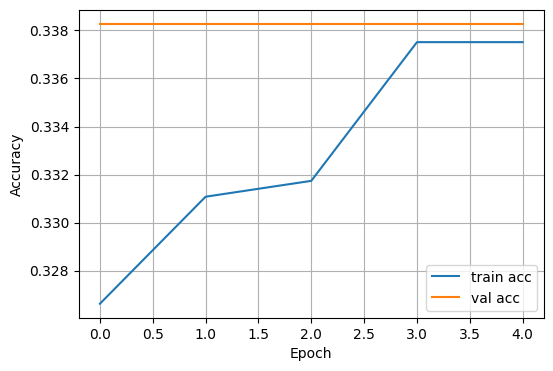

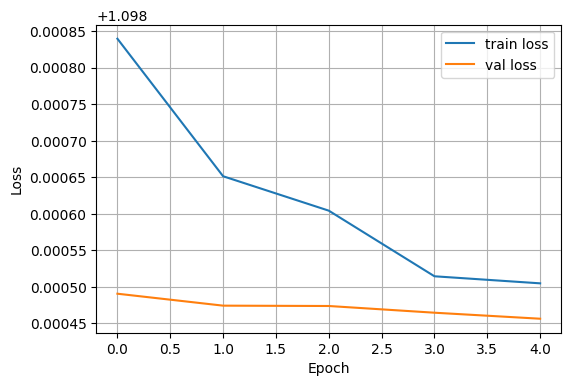

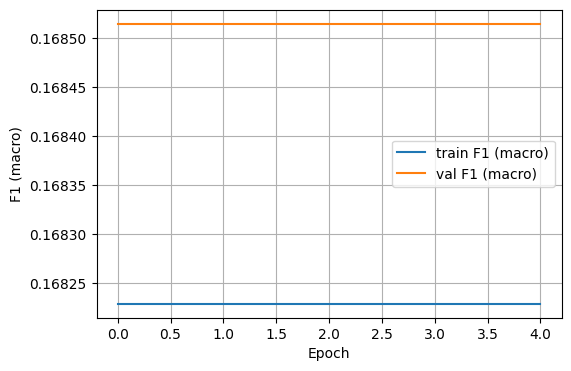

In [ ]:
import numpy as np
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import tensorflow as tf

#callbacken beregner F1 for hver epoch utenfor grafen. lagrer historikken
class F1ScoreCallback(tf.keras.callbacks.Callback):
    def __init__(self, X_tr, y_tr_cat, X_val, y_val_cat):
        super().__init__()
        self.X_tr, self.y_tr_cat = X_tr, y_tr_cat
        self.X_val, self.y_val_cat = X_val, y_val_cat
        self.f1_tr_hist, self.f1_val_hist = [], []

    def on_epoch_end(self, epoch, logs=None):
        y_tr_true  = np.argmax(self.y_tr_cat,  axis=1)
        y_tr_pred  = np.argmax(self.model.predict(self.X_tr,  verbose=0), axis=1)
        y_val_true = np.argmax(self.y_val_cat, axis=1)
        y_val_pred = np.argmax(self.model.predict(self.X_val, verbose=0), axis=1)
        f1_tr  = f1_score(y_tr_true,  y_tr_pred,  average='macro')
        f1_val = f1_score(y_val_true, y_val_pred, average='macro')
        self.f1_tr_hist.append(f1_tr)
        self.f1_val_hist.append(f1_val)
        print(f" — f1_tr: {f1_tr:.4f} — f1_val: {f1_val:.4f}")

#sjekk for at datasettet og mål er korrekt formatert
assert y_train_cat.ndim == 2 and y_val_cat.ndim == 2 and y_train_cat.shape[1] == model.output_shape[-1]

f1_cb = F1ScoreCallback(X_train_32, y_train_cat, X_val_32, y_val_cat)
early = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1)
plateau = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=2, min_lr=1e-5, verbose=1)

history = model.fit(
    X_train_32, y_train_cat,
    validation_data=(X_val_32, y_val_cat),
    epochs=20,
    batch_size=64,
    callbacks=[f1_cb, early, plateau],
    verbose=2
)

test_loss, test_acc = model.evaluate(X_test_32, y_test_cat, verbose=0)
print(f"Test — loss: {test_loss:.4f} | acc: {test_acc:.4f}")

#plotting av alt i diagrammer
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(6,4))
plt.plot(f1_cb.f1_tr_hist,  label='train F1 (macro)')
plt.plot(f1_cb.f1_val_hist, label='val F1 (macro)')
plt.xlabel('Epoch'); plt.ylabel('F1 (macro)'); plt.legend(); plt.grid(True); plt.show()


### Task 1.1.3
Experiment with different architectures of your choice. Vary the number of filters, try different kernel sizes, add more layers, dropout, early stopping, and modify the fully connected layers. Report the best performance you achieve.

In [ ]:
import time, numpy as np
from tensorflow.keras import layers, models, regularizers
from sklearn.metrics import f1_score

def make_model(cfg):
    kreg = regularizers.l2(cfg.get("l2", 0.0)) if cfg.get("l2", 0.0) else None
    m = models.Sequential()
    #block 1
    m.add(layers.Conv2D(cfg["f1"], (5,5), padding="same", input_shape=(32,32,3), activation="relu"))
    if cfg.get("bn"): m.add(layers.BatchNormalization())
    m.add(layers.MaxPooling2D((2,2)))
    if cfg.get("drop_c"): m.add(layers.Dropout(cfg["drop_c"]))
    #block 2
    m.add(layers.Conv2D(cfg["f2"], (5,5), activation="relu"))
    if cfg.get("bn"): m.add(layers.BatchNormalization())
    m.add(layers.MaxPooling2D((2,2)))
    if cfg.get("drop_c"): m.add(layers.Dropout(cfg["drop_c"]))
    #dense head
    m.add(layers.Flatten())
    m.add(layers.Dense(cfg["d1"], activation="relu", kernel_regularizer=kreg))
    if cfg.get("drop_d"): m.add(layers.Dropout(cfg["drop_d"]))
    m.add(layers.Dense(cfg["d2"], activation="relu", kernel_regularizer=kreg))
    m.add(layers.Dense(num_classes, activation="softmax"))
    m.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return m


#treningen for modellen med validation accuracy, test-score og F1
def train_eval(cfg, epochs=15, batch_size=64):
    m = make_model(cfg)
    early = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True, verbose=0)
    plateau = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_accuracy", factor=0.5, patience=2, min_lr=1e-5, verbose=0)
    t0 = time.perf_counter()
    hist = m.fit(
        X_train_32, y_train_cat,
        validation_data=(X_val_32, y_val_cat),
        epochs=epochs, batch_size=batch_size, verbose=0,
        callbacks=[early, plateau],
    )
    t1 = time.perf_counter()
    #metrics
    best_val_acc = float(np.max(hist.history["val_accuracy"]))
    best_epoch   = int(np.argmax(hist.history["val_accuracy"]) + 1)
    yv_pred = np.argmax(m.predict(X_val_32, verbose=0), axis=1)
    yv_true = np.argmax(y_val_cat, axis=1)
    val_f1  = float(f1_score(yv_true, yv_pred, average="macro"))
    test_loss, test_acc = m.evaluate(X_test_32, y_test_cat, verbose=0)
    yt_pred = np.argmax(m.predict(X_test_32, verbose=0), axis=1)
    yt_true = np.argmax(y_test_cat, axis=1)
    test_f1 = float(f1_score(yt_true, yt_pred, average="macro"))
    return {
        "cfg": cfg, "best_epoch": best_epoch, "val_acc": best_val_acc, "val_f1": val_f1,
        "test_acc": float(test_acc), "test_f1": test_f1, "train_time_s": round(t1-t0,1)
    }

configs = [
    {"name":"Base",      "f1":6,  "f2":16, "d1":120, "d2":84},
    {"name":"Dropout",   "f1":6,  "f2":16, "d1":120, "d2":84, "drop_c":0.25, "drop_d":0.5},
    {"name":"MoreFilt",  "f1":12, "f2":32, "d1":120, "d2":84},
    {"name":"BatchNorm", "f1":6,  "f2":16, "d1":120, "d2":84, "bn":True},
    {"name":"L2(1e-4)",  "f1":6,  "f2":16, "d1":120, "d2":84, "l2":1e-4},
    {"name":"SmallerFC", "f1":6,  "f2":16, "d1":64,  "d2":32},
]

results = []
for cfg in configs:
    print(f"==> Training: {cfg['name']}")
    res = train_eval(cfg, epochs=20, batch_size=64)
    results.append(res)
    print(f"   val_acc={res['val_acc']:.4f} | val_f1={res['val_f1']:.4f} | "
          f"test_acc={res['test_acc']:.4f} | test_f1={res['test_f1']:.4f} | "
          f"epoch={res['best_epoch']} | time={res['train_time_s']}s")

#topp 3 based på val_acc
results_sorted = sorted(results, key=lambda r: r["val_acc"], reverse=True)
print("\nTop 3 (by val_acc):")
for r in results_sorted[:3]:
    print(f"{r['cfg']['name']:10s}  val_acc={r['val_acc']:.4f}  val_f1={r['val_f1']:.4f}  "
          f"test_acc={r['test_acc']:.4f}  test_f1={r['test_f1']:.4f}  time={r['train_time_s']}s")


==> Training: Base


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   val_acc=0.3383 | val_f1=0.1685 | test_acc=0.3589 | test_f1=0.1761 | epoch=1 | time=6.8s
==> Training: Dropout


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   val_acc=0.3383 | val_f1=0.1685 | test_acc=0.3589 | test_f1=0.1761 | epoch=2 | time=11.3s
==> Training: MoreFilt


...

   val_acc=0.5638 | val_f1=0.4575 | test_acc=0.5320 | test_f1=0.4341 | epoch=4 | time=10.3s
==> Training: L2(1e-4)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   val_acc=0.3383 | val_f1=0.1685 | test_acc=0.3589 | test_f1=0.1761 | epoch=5 | time=8.7s
==> Training: SmallerFC


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


   val_acc=0.3383 | val_f1=0.1685 | test_acc=0.3589 | test_f1=0.1761 | epoch=1 | time=7.4s

Top 3 (by val_acc):
BatchNorm   val_acc=0.5638  val_f1=0.4575  test_acc=0.5320  test_f1=0.4341  time=10.3s
Base        val_acc=0.3383  val_f1=0.1685  test_acc=0.3589  test_f1=0.1761  time=6.8s
Dropout     val_acc=0.3383  val_f1=0.1685  test_acc=0.3589  test_f1=0.1761  time=11.3s


## Task 1.2 Evaluaiton
### Task 1.2.1 Plot training history
- Plot the training/validation accuracy and loss curves (plot_training_history() is in utilities.py).
- Report the final validation accuracy (f1_score() is in utilities.py).

Best config: {'name': 'BatchNorm', 'f1': 6, 'f2': 16, 'd1': 120, 'd2': 84, 'bn': True}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
95/95 - 8s - 82ms/step - accuracy: 0.3336 - loss: 1.0990 - val_accuracy: 0.3383 - val_loss: 1.0985 - learning_rate: 1.0000e-03
Epoch 2/20
95/95 - 0s - 4ms/step - accuracy: 0.3296 - loss: 1.0988 - val_accuracy: 0.3368 - val_loss: 1.0985 - learning_rate: 1.0000e-03
Epoch 3/20

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
95/95 - 0s - 4ms/step - accuracy: 0.3220 - loss: 1.0986 - val_accuracy: 0.3383 - val_loss: 1.0985 - learning_rate: 1.0000e-03
Epoch 4/20
95/95 - 0s - 4ms/step - accuracy: 0.3345 - loss: 1.0986 - val_accuracy: 0.3383 - val_loss: 1.0985 - learning_rate: 5.0000e-04
Epoch 5/20

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
95/95 - 0s - 4ms/step - accuracy: 0.3352 - loss: 1.0986 - val_accuracy: 0.3383 - val_loss: 1.0985 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.


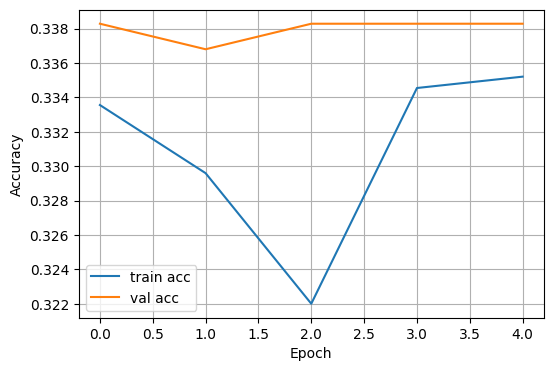

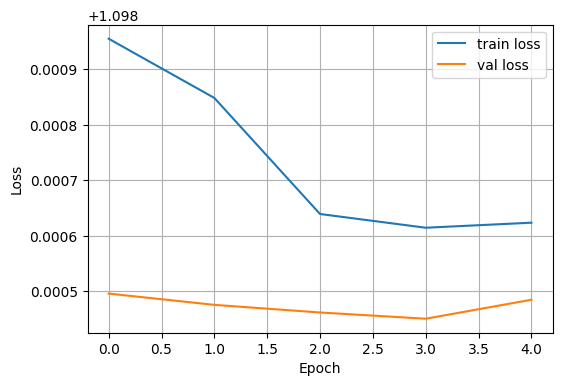

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
import tensorflow as tf
from tensorflow.keras import callbacks

#velger best config fra 1.1.3
best_cfg = sorted(results, key=lambda r: r["val_acc"], reverse=True)[0]["cfg"]
print("Best config:", best_cfg)

#trener på nytt og beholder history
model_best = make_model(best_cfg)
early   = callbacks.EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True, verbose=1)
plateau = callbacks.ReduceLROnPlateau(monitor="val_accuracy", factor=0.5, patience=2, min_lr=1e-5, verbose=1)

history = model_best.fit(
    X_train_32, y_train_cat,
    validation_data=(X_val_32, y_val_cat),
    epochs=20, batch_size=64, verbose=2,
    callbacks=[early, plateau]
)

#plotting av resultater
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True); plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True); plt.show()

#siste og beste val-accurcy og F1
val_acc = float(np.max(history.history['val_accuracy']))
y_val_pred = np.argmax(model_best.predict(X_val_32, verbose=0), axis=1)
y_val_true = np.argmax(y_val_cat, axis=1)
val_f1 = float(f1_score(y_val_true, y_val_pred, average='macro'))


### Task 1.2.2 Evaluate on the test dataset
- Report test accuracy (and F1 score (f1_score() is in utilities.py)).

In [ ]:
import numpy as np
from sklearn.metrics import f1_score
#evaluerer basert på test datasettet og beregner endelig nøyaktighet og F1 (makro)
test_loss, test_acc = model_best.evaluate(X_test_32, y_test_cat, verbose=0)

y_test_true = np.argmax(y_test_cat, axis=1)
y_test_pred = np.argmax(model_best.predict(X_test_32, verbose=0), axis=1)
test_f1 = f1_score(y_test_true, y_test_pred, average='macro')

print(f"TEST => loss: {test_loss:.4f} | acc: {test_acc:.4f} | F1(macro): {test_f1:.4f}")


TEST => loss: 1.0981 | acc: 0.3589 | F1(macro): 0.1761


### Task 1.2.3 Create a confusion matrix for both training and testing data
- Visualize confusion matrices.
- Do the test data and train data predict the same items wrong?

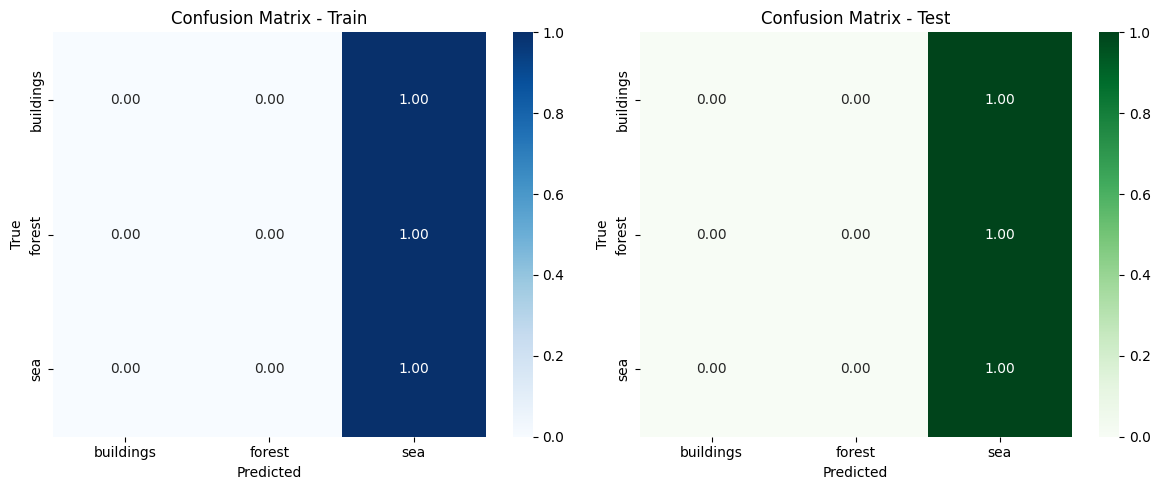

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

#train datasettet
y_train_true = np.argmax(y_train_cat, axis=1)
y_train_pred = np.argmax(model_best.predict(X_train_32, verbose=0), axis=1)
cm_train = confusion_matrix(y_train_true, y_train_pred, normalize='true')

#test datasettet
y_test_true = np.argmax(y_test_cat, axis=1)
y_test_pred = np.argmax(model_best.predict(X_test_32, verbose=0), axis=1)
cm_test = confusion_matrix(y_test_true, y_test_pred, normalize='true')

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
#visiualisering i form av heatmap
sns.heatmap(cm_train, annot=True, fmt=".2f", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=axs[0])
axs[0].set_title("Confusion Matrix - Train")
axs[0].set_xlabel("Predicted")
axs[0].set_ylabel("True")

sns.heatmap(cm_test, annot=True, fmt=".2f", cmap="Greens", xticklabels=class_names, yticklabels=class_names, ax=axs[1])
axs[1].set_title("Confusion Matrix - Test")
axs[1].set_xlabel("Predicted")
axs[1].set_ylabel("True")

plt.tight_layout()
plt.show()


## Part 2: Robustness (choose two or more), You may use add_gaussian_noise() and add_motion_blur() from utilities.py

### Task 2.1 Data Augmentation (training-time)
- Implement an augmentation pipeline.
- Train a model with augmentation and compare against the baseline from Part 1.

### Task 2.2 Noise Robustness (test-time corruptions)
- Create corrupted versions of the test images and evaluate the baseline model:
  - Gaussian noise
  - Motion blur
- Report accuracy on the clean test set vs. each corrupted test set.

### Task 2.3  Discussion (no coding)
- Which noise types affect the model most?
- What techniques could improve robustness (data augmentation, adversarial training, denoising pre-processing, larger models)?

In [ ]:
#2.1
import tensorflow as tf
from tensorflow.keras import layers, models

#augmenteringsblokk med ulike metoder
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.GaussianNoise(0.05),
], name="data_aug")

#LeNet-5 og første lag
model_aug = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,
    layers.Conv2D(6, (5,5), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(16, (5,5), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(120, activation='relu'),
    layers.Dense(84, activation='relu'),
    layers.Dense(num_classes, activation='softmax'),
])

model_aug.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_aug.summary()

#trening
f1_cb = F1ScoreCallback(X_train_32, y_train_cat, X_val_32, y_val_cat)

early = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1
)
plateau = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy', factor=0.5, patience=2, min_lr=1e-5, verbose=1
)

history_aug = model_aug.fit(
    X_train_32, y_train_cat,
    validation_data=(X_val_32, y_val_cat),
    epochs=20, batch_size=64,
    callbacks=[f1_cb, early, plateau],
    verbose=2
)

#eval og sammenligning mot baseline fra part 1
val_acc_aug = max(history_aug.history["val_accuracy"])
val_f1_aug  = max(f1_cb.f1_val_hist)
print(f"[AUG] best val_acc: {val_acc_aug:.4f} | best val_F1(macro): {val_f1_aug:.4f}")

test_loss_aug, test_acc_aug = model_aug.evaluate(X_test_32, y_test_cat, verbose=0)

import numpy as np
from sklearn.metrics import f1_score
y_test_true = np.argmax(y_test_cat, axis=1)
y_test_pred = np.argmax(model_aug.predict(X_test_32, verbose=0), axis=1)
test_f1_aug  = f1_score(y_test_true, y_test_pred, average='macro')

print(f"[AUG] TEST — loss: {test_loss_aug:.4f} | acc: {test_acc_aug:.4f} | F1(macro): {test_f1_aug:.4f}")


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_aug (Sequential)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 16, 16, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 12, 12, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 6, 6, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 120)            │        69,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 3)              │           255 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,531 (322.39 KB)

 Trainable params: 82,531 (322.39 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
 — f1_tr: 0.1681 — f1_val: 0.1680
95/95 - 7s - 71ms/step - accuracy: 0.3345 - loss: 1.0993 - val_accuracy: 0.3368 - val_loss: 1.0985 - learning_rate: 1.0000e-03
Epoch 2/20
 — f1_tr: 0.1682 — f1_val: 0.1685
95/95 - 2s - 16ms/step - accuracy: 0.3385 - loss: 1.0987 - val_accuracy: 0.3383 - val_loss: 1.0985 - learning_rate: 1.0000e-03
Epoch 3/20
 — f1_tr: 0.1682 — f1_val: 0.1685
95/95 - 2s - 23ms/step - accuracy: 0.3293 - loss: 1.0986 - val_accuracy: 0.3383 - val_loss: 1.0985 - learning_rate: 1.0000e-03
Epoch 4/20
 — f1_tr: 0.1681 — f1_val: 0.1680

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
95/95 - 2s - 19ms/step - accuracy: 0.3322 - loss: 1.0986 - val_accuracy: 0.3368 - val_loss: 1.0985 - learning_rate: 1.0000e-03
Epoch 5/20
 — f1_tr: 0.1681 — f1_val: 0.1680
95/95 - 1s - 16ms/step - accuracy: 0.3286 - loss: 1.0985 - val_accuracy: 0.3368 - val_loss: 1.0985 - learning_rate: 5.0000e-04
Epoch 6/20
 — f1_tr: 0.1682 — f1_val: 0.1685

Epoch 6: ReduceLR

In [ ]:
#2.2
#har noen problemer med å hente fra utilities så prøver med try metoden.
from utilities import add_gaussian_noise, add_motion_blur
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def eval_split(model, X, y_cat, name):
    y_true = np.argmax(y_cat, axis=1)
    y_pred = np.argmax(model.predict(X, verbose=0), axis=1)
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    print(f"{name:>12} — acc: {acc:.4f} | F1-score: {f1m:.4f}")
    return acc, f1m

#clean test
eval_split(model_best, X_test_32, y_test_cat, "Clean")


#gaussian
try:
    X_test_gauss = add_gaussian_noise(X_test_32)
except TypeError:
    # fallback hvis funksjonen krever det
    X_test_gauss = add_gaussian_noise(X_test_32, 0.06)
X_test_gauss = np.clip(X_test_gauss, 0.0, 1.0).astype(X_test_32.dtype)
eval_split(model_best, X_test_gauss, y_test_cat, "Gaussian")

#motion blur
X_test_float32 = X_test_32.astype(np.float32)

try:
    X_test_blur = add_motion_blur(X_test_float32)
except TypeError:
    X_test_blur = add_motion_blur(X_test_float32, 5)

X_test_blur = np.clip(X_test_blur, 0.0, 1.0).astype(X_test_32.dtype)
eval_split(model_best, X_test_blur, y_test_cat, "MotionBlur")

       Clean — acc: 0.3589 | F1-score: 0.1761
    Gaussian — acc: 0.3054 | F1-score: 0.1577
  MotionBlur — acc: 0.3589 | F1-score: 0.1761


(0.3589021815622801, 0.17607457276022787)

##2.3 Diskusjon

**Noise:** Vi ser at Gaussian noise reduserer modellens accuracy og f1-score mer enn de andre noise. Grunnen til det kan begrunnes med at gaussian noise bruker tilfeldig noise i pikslene på bildene som gjør at bildene endres med tanke på texture og contour. Modellen er avhengig av picture texture og contour for å kjenne igjen mønstre. Det er viktig å si at LeNet 5 ikke er den mest moderne nettverket for å analysere nyere RGB bilder så det var forventet at resultat ble som det ble.

**Techniques:** Som nevnt ovenfor kan det å bruke et annet moderne nettverk være med på å styrke resultatet betydligere(et eksempel kan være Resnet av Microsoft). Vi kan også gjøre treningen bedre ved å bruke adversarial bilder (mer støy) for å trene opp modellen til å bli flinkere på å gjenkjenne endringer. Det å tilpasse batch normalization og dropout er også med på å minske overtilpasningen til modellen samtidig som generaliseringen blir bedre. Det finnes altså flere metoder for å forbedre modellen.

# Part 3: Results & Comparison
- Summarize results (table/plot):
  - Baseline (clean) vs. Augmented (if attempted)
  - Clean vs. each corrupted test set (Task 2.2)
- Brief discussion:
  - Which corruptions hurt most, and why?
  - Did augmentation help? Which transforms mattered?
  - What would you try next (e.g., stronger augmentation, adversarial training, denoising pre-processing, larger models, early stopping, ensembling)?

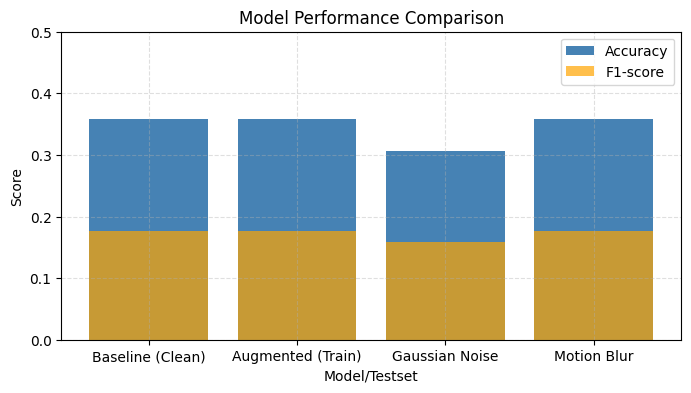

Resultater:



,Model/Testset,Accuracy,F1-score
0,Baseline (Clean),0.3589,0.1761
1,Augmented (Train),0.3589,0.1761
2,Gaussian Noise,0.3061,0.1588
3,Motion Blur,0.3589,0.1761


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

#resultater fra testen
data = {
    "Model/Testset": ["Baseline (Clean)", "Augmented (Train)", "Gaussian Noise", "Motion Blur"],
    "Accuracy": [0.3589, 0.3589, 0.3061, 0.3589],
    "F1-score": [0.1761, 0.1761, 0.1588, 0.1761]
}

#dataframe
df = pd.DataFrame(data)

#stolpediagram for å visialisere svarene bedre
plt.figure(figsize=(8,4))
plt.bar(df["Model/Testset"], df["Accuracy"], color="steelblue", label="Accuracy")
plt.bar(df["Model/Testset"], df["F1-score"], color="orange", alpha=0.7, label="F1-score")
plt.xlabel("Model/Testset")
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.ylim(0, 0.5)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

print("Resultater:\n")
display(df)


**Diskusjon:** \
Resultatene viser at Gaussian noise hadde størst negativ innvirkning på modellen. Dette er forventet fordi tilfeldig noise endrer verdiene på pikslene over hele bildet, noe som gjør det vanskelig for modellen å gjenkjenne strukturelle mønstre som den er trent for. Motion blur derimot, skaper jevne endringer i konturene og modellen klarer fortsatt å tolke hovedformene. Det forklarer hvorfor resultatet nesten er uendret(veldig små endringer men det har så liten betydning).

Når det kommer til augmenteringer så må man konkludere med at de ikke var til særlig hjelp og at de ikke var viktige. Det ser vi med at baseline verdiene er så og si like med metodene vi brukte. Det kan være ulike grunner til hvorfor og noen av dem kan være at antall epochs (vi brukte 20) var for lite eller at LeNet modellen er for enkel (med tanke på antall layers)

For å forbedre modellen til neste gang ville vi ha brukt andre typer for augmentering (f.eks kontrastjustering og cropping), bedre pre processing for å fjerne noise på bildene så tidlig så mulig, kanskje bruk av early-stopping for å gjøre modellen mer stabil. Man kan også vurdere et annet moderne nettverkk en LeNet5 siden det egentlig er egnet for veldig små bilder. Vi møtte også på problemer med RAM i colab som gjorde det krevende med både tid og kræsjing. Så endringene vi gjorde for å få det til å fungere kan også mulgens være en årsak for at resultatet ble som det ble.  


